##setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#svm == nn  choose nn since it has higher area under the curve
speechTimingSamples = ['BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018', 'BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019']
speechTimingLvProbs = [np.float64(0.9134137939498091), np.float64(0.7542621464154818), np.float64(0.8807522048907025), np.float64(0.8420179933929113), np.float64(0.9045762142058907), np.float64(0.5411041440752383), np.float64(0.49472955162192334), np.float64(0.6909109782986166), np.float64(0.6260074282817983), np.float64(0.6450468238483777), np.float64(0.44749877594971), np.float64(0.8893177916143266), np.float64(0.6618182018222967), np.float64(0.9057651576683673), np.float64(0.809242860002105), np.float64(0.8641602323552653), np.float64(0.6847303855575708), np.float64(0.7417953409906447), np.float64(0.6542634122348312), np.float64(0.6149500531195463), np.float64(0.6343714180611691), np.float64(0.7100961413889513), np.float64(0.8423354590057469), np.float64(0.9368074872245851), np.float64(0.6537594934718235), np.float64(0.5782012047946931), np.float64(0.7385644055642547), np.float64(0.30731842054596936), np.float64(0.6590404119516491), np.float64(0.936404749778971), np.float64(0.5583949516775191), np.float64(0.8242574251261399), np.float64(0.37529277442633135), np.float64(0.43230933095012436)]
speechTimingProbDict = dict(zip(speechTimingSamples,speechTimingLvProbs))
speechTimingDF = pd.DataFrame(speechTimingProbDict.items(),columns=['Sample_ID', 'Speech-timing: P(lv)'])
speechTimingDF.head()

,Sample_ID,Speech-timing: P(lv)
0,BILP006,0.913414
1,BILP009,0.754262
2,BILP013,0.880752
3,BILP022,0.842018
4,BILP024,0.904576


In [ ]:
wordParamSamples = ['BILP006_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP009_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP013_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP022_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP024_BACC016_PicnicScene_Spa_Pre_20240130_Coded.flo.cex', 'BILP026_BACC023_PicnicScene_Spa_Obs1_20240320_Coded.flo.cex', 'BISE004_Pre-Tx_Spa_WABPicnic_Coded.flo.cex', 'BISE005_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BISE013_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BISE016_BACC014_PicnicScene_Spa_Pre_20240117_Coded.flo.cex', 'BISE018_BACC019_PicnicScene_Spa_Pre_20240515.flo.cex', 'BILP007_Cat_PicnicScene_Post_coded.flo.cex', 'BILP008_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP010_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP011_PicnicScene_Cat_Pre_Coded.flo.cex', 'BILP012_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP014_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP015_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP017_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP018_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP019_PreTX_Cat_PicnicDescription_Coded.flo.cex', 'BILP020_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP021_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP025_BACC020_PicnicScene_Cat_Pre_20240430_Coded.flo.cex', 'BILP027_BACC81_PicnicScene_Cat_Pre_20240529_Coded.flo.cex', 'BILP028_BACC116_PicnicScene_Cat_Pre_20240923_Coded.flo.cex', 'BILP029_BACC109_PicnicScene_Cat_Pre_20241002_Coded.flo.cex', 'BIOBS003_BACC111_PicnicScene_Cat_Obs1_20241106_Coded.flo.cex', 'BIOBS004_BACC50_PicnicScene_Cat_EB1_20240801_Coded.flo.cex', 'BIOBS005_BACC91_PicnicScene_Cat_EB1_20241009_Coded.flo.cex', 'BISE010_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BISE011_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BISE014_BACC005_PicnicScene_Cat_Pre_20230622_Coded.flo.cex', 'BISE019_BACC114_PicnicScene_Cat_Pre_20240903_Coded.flo.cex']
wordParamSamples = [sample.split('_')[0] for sample in wordParamSamples]
wordParamPredProbs = [np.float64(0.9565217391304348), np.float64(0.9565217391304348), np.float64(0.9565217391304348), np.float64(0.9565217391304348), np.float64(0.0), np.float64(0.9565217391304348), np.float64(0.08571428571428573), np.float64(0.05084745762711864), np.float64(0.05084745762711864), np.float64(0.8961038961038962), np.float64(0.05084745762711864), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.0), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9565217391304348), np.float64(0.9053497942386833), np.float64(0.9053497942386833), np.float64(0.9583333333333334), np.float64(0.9053497942386833), np.float64(1.0), np.float64(0.25), np.float64(0.05084745762711864), np.float64(0.05084745762711864)]
wordParamsSampleProbDict = dict(zip(wordParamSamples,wordParamPredProbs))
wordParamsDF = pd.DataFrame(wordParamsSampleProbDict.items(),columns=['Sample_ID', 'Word Ratings: P(lv)'])
wordParamsDF.head()

,Sample_ID,Word Ratings: P(lv)
0,BILP006,0.956522
1,BILP009,0.956522
2,BILP013,0.956522
3,BILP022,0.956522
4,BILP024,0.000000


In [ ]:
imageTextSimSampleNames = ['BILP007_Cat_PicnicScene_Post_coded.flo.cex', 'BILP008_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP010_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP011_PicnicScene_Cat_Pre_Coded.flo.cex', 'BILP012_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP014_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP015_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP017_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP018_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP019_PreTX_Cat_PicnicDescription_Coded.flo.cex', 'BILP020_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP021_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BILP025_BACC020_PicnicScene_Cat_Pre_20240430_Coded.flo.cex', 'BILP027_BACC81_PicnicScene_Cat_Pre_20240529_Coded.flo.cex', 'BILP028_BACC116_PicnicScene_Cat_Pre_20240923_Coded.flo.cex', 'BILP029_BACC109_PicnicScene_Cat_Pre_20241002_Coded.flo.cex', 'BIOBS003_BACC111_PicnicScene_Cat_Obs1_20241106_Coded.flo.cex', 'BIOBS004_BACC50_PicnicScene_Cat_EB1_20240801_Coded.flo.cex', 'BIOBS005_BACC91_PicnicScene_Cat_EB1_20241009_Coded.flo.cex', 'BISE010_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BISE011_PreTx_Cat_WABPicnic_Coded.flo.cex', 'BISE014_BACC005_PicnicScene_Cat_Pre_20230622_Coded.flo.cex', 'BISE019_BACC114_PicnicScene_Cat_Pre_20240903_Coded.flo.cex', 'BILP006_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP009_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP013_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP022_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BILP024_BACC016_PicnicScene_Spa_Pre_20240130_Coded.flo.cex', 'BILP026_BACC023_PicnicScene_Spa_Obs1_20240320_Coded.flo.cex', 'BISE004_Pre-Tx_Spa_WABPicnic_Coded.flo.cex', 'BISE005_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BISE013_PreTx_Spa_WABPicnic_Coded.flo.cex', 'BISE016_BACC014_PicnicScene_Spa_Pre_20240117_Coded.flo.cex', 'BISE018_BACC019_PicnicScene_Spa_Pre_20240515.flo.cex']
imageTextSimSampleNames = [sample.split('_')[0] for sample in imageTextSimSampleNames]
imageTextSimLvProbs = [np.float64(0.5967919842815965), np.float64(0.5176185032743965), np.float64(0.8350420880075204), np.float64(0.3086103002521109), np.float64(0.437856997521382), np.float64(0.43905399462004807), np.float64(0.6170931185648949), np.float64(0.4933868555103111), np.float64(0.4881937183941172), np.float64(0.806740963765659), np.float64(0.6984485815202426), np.float64(0.6880464055681036), np.float64(0.5357192109811658), np.float64(0.6317339876430127), np.float64(0.6118773966131381), np.float64(0.5050838066053658), np.float64(0.7477631416121194), np.float64(0.775421539208995), np.float64(0.19845950796098658), np.float64(0.38916325908735466), np.float64(0.31824574034255976), np.float64(0.6300379657785248), np.float64(0.20915023145387976), np.float64(0.5091000499854698), np.float64(0.6907697565003769), np.float64(0.5721511457394922), np.float64(0.6879788593773533), np.float64(0.6084195908230622), np.float64(0.7518562731532602), np.float64(0.3694279057063298), np.float64(0.41965159436094895), np.float64(0.22233954166495953), np.float64(0.5213604878710153), np.float64(0.27025405243449163)]

 #[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.6923076923076923), np.float64(1.0), np.float64(0.05084745762711864), np.float64(0.05084745762711864), np.float64(0.8873239436619719), np.float64(0.05084745762711864), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.05084745762711864), np.float64(0.9230769230769231), np.float64(0.05084745762711864), np.float64(1.0), np.float64(0.0)]
temp = list(zip(imageTextSimSampleNames,imageTextSimLvProbs))
imageTextSimDF = pd.DataFrame(temp,columns=['Sample_ID', 'Image-Text Sim: P(lv)'])
imageTextSimDF.head()

,Sample_ID,Image-Text Sim: P(lv)
0,BILP007,0.596792
1,BILP008,0.517619
2,BILP010,0.835042
3,BILP011,0.308610
4,BILP012,0.437857


In [ ]:
lingSamples = ['BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018', 'BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019']
lingPredProbs =  [np.float64(0.9788937194909416), np.float64(0.9767829247526669), np.float64(0.9748794316937894), np.float64(0.9748794316937894), np.float64(0.9767829247526669), np.float64(0.18002487890185268), np.float64(0.20476055201554555), np.float64(0.1217284907869408), np.float64(0.7663011572067827), np.float64(0.8789997567243873), np.float64(0.21149364191947392), np.float64(0.9361263873787692), np.float64(0.9328597287461101), np.float64(0.9361263873787692), np.float64(0.9209399821682948), np.float64(0.8562001328930032), np.float64(0.9209399821682948), np.float64(0.9361263873787692), np.float64(0.9361263873787692), np.float64(0.9361263873787692), np.float64(0.9103932558825174), np.float64(0.9361263873787692), np.float64(0.9361263873787692), np.float64(0.9361263873787692), np.float64(0.9361263873787692), np.float64(0.41093608669753934), np.float64(0.06789158604565648), np.float64(0.9361263873787692), np.float64(0.1120652710703222), np.float64(0.9292109906542815), np.float64(0.9002777177129206), np.float64(0.03562002501684986), np.float64(0.8825362782866897), np.float64(0.2006010541847775)]
lingSampleProbDict = dict(zip(lingSamples,lingPredProbs))
lingDF = pd.DataFrame(lingSampleProbDict.items(),columns=['Sample_ID', 'Linguistic: P(lv)'])
lingDF.head()

,Sample_ID,Linguistic: P(lv)
0,BILP006,0.978894
1,BILP009,0.976783
2,BILP013,0.974879
3,BILP022,0.974879
4,BILP024,0.976783


In [ ]:
domEnsembleDF = pd.merge(imageTextSimDF,speechTimingDF,on='Sample_ID')
domEnsembleDF = pd.merge(domEnsembleDF,wordParamsDF,on='Sample_ID')
domEnsembleDF = pd.merge(domEnsembleDF,lingDF,on='Sample_ID')
domEnsembleDF.head()

,Sample_ID,Image-Text Sim: P(lv),Speech-timing: P(lv),Word Ratings: P(lv),Linguistic: P(lv)
0,BILP007,0.596792,0.889318,0.90535,0.936126
1,BILP008,0.517619,0.661818,0.90535,0.932860
2,BILP010,0.835042,0.905765,0.90535,0.936126
3,BILP011,0.308610,0.809243,0.00000,0.920940
4,BILP012,0.437857,0.864160,0.90535,0.856200


In [ ]:
print(list(domEnsembleDF['Sample_ID']))

['BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019', 'BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018']


In [ ]:
domEnsembleDF.shape

(34, 5)

In [ ]:
domEnsembleDF.to_csv('lvProbs_Dominant.csv',index=False)
from google.colab import files
files.download('lvProbs_Dominant.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data_X = domEnsembleDF.drop('Sample_ID',axis=1)
data_X.head()

,Image-Text Sim: P(lv),Speech-timing: P(lv),Word Ratings: P(lv),Linguistic: P(lv)
0,0.596792,0.889318,0.90535,0.936126
1,0.517619,0.661818,0.90535,0.932860
2,0.835042,0.905765,0.90535,0.936126
3,0.308610,0.809243,0.00000,0.920940
4,0.437857,0.864160,0.90535,0.856200


In [ ]:
def getClass(filename):
  if 'BISE' in filename:
    return 'nfv'
  if 'BILP' in filename:
    return 'lv'
  if 'BIOBS003' in filename or 'BIOBS005' in filename:
    return 'lv'
  if 'BIOBS004' in filename:
    return 'nfv'

In [ ]:
ensembleY = domEnsembleDF['Sample_ID'].apply(getClass)
data_Y = ensembleY

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
print(list(data_Y))

['lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'nfv', 'lv', 'nfv', 'nfv', 'nfv', 'nfv', 'lv', 'lv', 'lv', 'lv', 'lv', 'lv', 'nfv', 'nfv', 'nfv', 'nfv', 'nfv']


In [ ]:
data_Y = [0 if y == 'nfv' else 1 for y in list(data_Y)]
print(data_Y)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


#ML Methods

Extra functionalities: see predicted time needed, each fold's best model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
def looNCVWithTiming(param_grid, clf):
  import numpy as np
  import pandas as pd
  from sklearn.model_selection import GridSearchCV, LeaveOneOut
  from sklearn.inspection import permutation_importance
  from sklearn.metrics import accuracy_score
  from tqdm import tqdm
  import time
  from sklearn.model_selection import cross_val_predict
  from sklearn.metrics import confusion_matrix
  from sklearn.metrics import classification_report
  X = data_X
  y = np.array(data_Y)

# --- Storage ---
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()
  numInnerFolds = 5

  print("Running nested LOO CV")
  from sklearn.preprocessing import StandardScaler
  from sklearn.decomposition import PCA
  from sklearn.neural_network import MLPClassifier
  from sklearn.pipeline import Pipeline

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    start_time = time.time()
    #scaler = StandardScaler()
    grid_search = GridSearchCV(clf, param_grid, cv=numInnerFolds, scoring='f1_macro',n_jobs=-1) #n_jobs ensures parrallelization speedup
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"Best params for outer fold {test_idx}: {grid_search.best_params_}")

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1] #1 means P(aphasia)
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: cv loop lasted {elapsed:.2f} seconds")

# --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=['nfvPPA', 'lvPPA']))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)

  from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
  import numpy as np
  import matplotlib.pyplot as plt
  fpr, tpr, thresholds = roc_curve(data_Y, test_preds_probs)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc='lower right')
  plt.grid()
  plt.show()

# Post-Hoc Threshold Tuning
  optimal_idx = np.argmax(tpr - fpr)
  optimal_threshold = thresholds[optimal_idx]
  print(f"Optimal Threshold: {optimal_threshold}")

# Apply the optimal threshold
  adjusted_predictions = (test_preds_probs >= optimal_threshold).astype(int)
  print("Predictions using adjusted threshold:", adjusted_predictions)

# Evaluate the new predictions
  print("Confusion Matrix with Adjusted Threshold:")
  print(confusion_matrix(data_Y, adjusted_predictions))
  print("Classification Report with Adjusted Threshold:")
  print(classification_report(data_Y, adjusted_predictions, target_names=['nfvPPA', 'lvPPA']))

  print("Prettier confusion matrix for adjusted threshold:")
  generateBetterConfusionMatrix(test_true, adjusted_predictions)
  print("Prettier confusion matrix for default threshold:")
  generateBetterConfusionMatrix(test_true, test_preds)

In [ ]:
def generateBetterConfusionMatrix(test_true,test_preds):
  import matplotlib.pyplot as plt
  import numpy as np
  from sklearn.metrics import confusion_matrix

# Compute confusion matrix and normalized version
  cm = confusion_matrix(test_true, test_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  row_totals = cm.sum(axis=1)


  plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.labelsize': 16,     # x/y label size
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
  })


# Plot setup
  fig, ax = plt.subplots()
  im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)  # Use 'Blues'
  cbar = plt.colorbar(im, ax=ax)

# Axis setup
  class_names = ['nfvPPA', 'lvPPA']
  ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True diagnosis',
       xlabel='Predicted diagnosis')
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = row_totals[i]
        percent = cm_normalized[i, j] * 100

        # Get brightness to set text color (luminance rule of thumb)
        brightness = im.cmap(cm_normalized[i, j])[:3]  # RGB
        luminance = 0.299 * brightness[0] + 0.587 * brightness[1] + 0.114 * brightness[2]
        text_color = 'black' if luminance > 0.5 else 'white'

        ax.text(j, i, f'{percent:.0f}% ({count}/{total})',
                ha='center', va='center', color=text_color, fontsize=14)

  plt.tight_layout()
  plt.show()


#Decision Tree (80%)

In [ ]:
decision_tree_param_grid = {
    "class_weight": ["balanced", None],
    "criterion": ["gini"],
    "max_depth": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:03<01:46,  3.24s/it]

Best params for outer fold [0]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 0: cv loop lasted 3.24 seconds


Outer folds:   6%|▌         | 2/34 [00:03<00:52,  1.64s/it]

Best params for outer fold [1]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 1: cv loop lasted 0.52 seconds


...

Best params for outer fold [31]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': None}
Test idx 31: cv loop lasted 0.90 seconds


Outer folds:  97%|█████████▋| 33/34 [00:31<00:00,  1.15it/s]

Best params for outer fold [32]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 32: cv loop lasted 0.85 seconds


Outer folds: 100%|██████████| 34/34 [00:32<00:00,  1.06it/s]

Best params for outer fold [33]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': None}
Test idx 33: cv loop lasted 0.89 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.62      0.80      0.70        10
       lvPPA       0.90      0.79      0.84        24

    accuracy                           0.79        34
   macro avg       0.76      0.80      0.77        34
weighted avg       0.82      0.79      0.80        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Evaluation

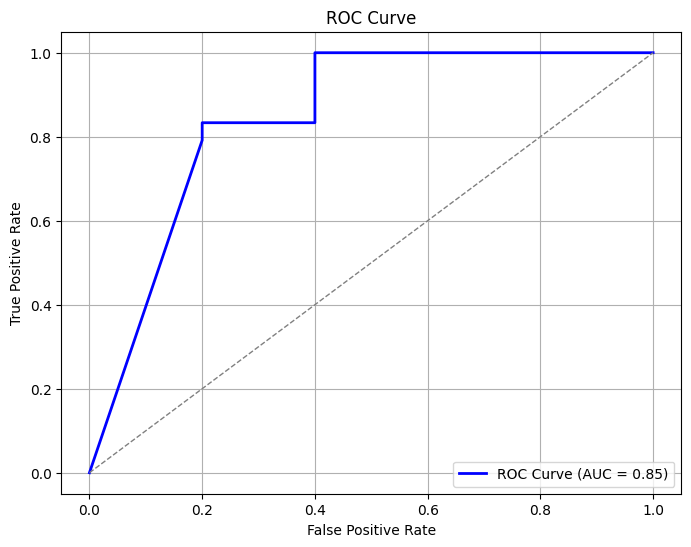

Optimal Threshold: 0.14814814814814817
Predictions using adjusted threshold: [1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 8  2]
 [ 4 20]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.67      0.80      0.73        10
       lvPPA       0.91      0.83      0.87        24

    accuracy                           0.82        34
   macro avg       0.79      0.82      0.80        34
weighted avg       0.84      0.82      0.83        34

Prettier confusion matrix for adjusted threshold:


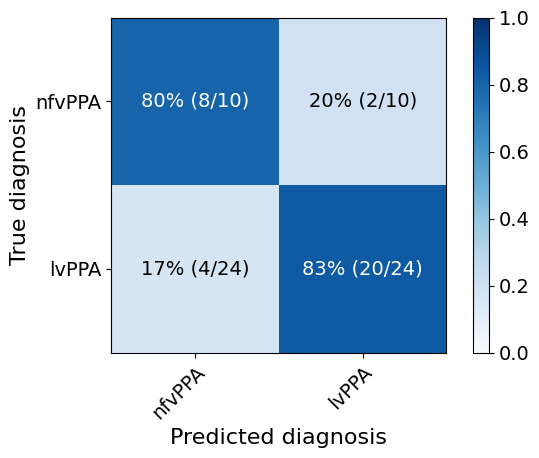

Prettier confusion matrix for default threshold:


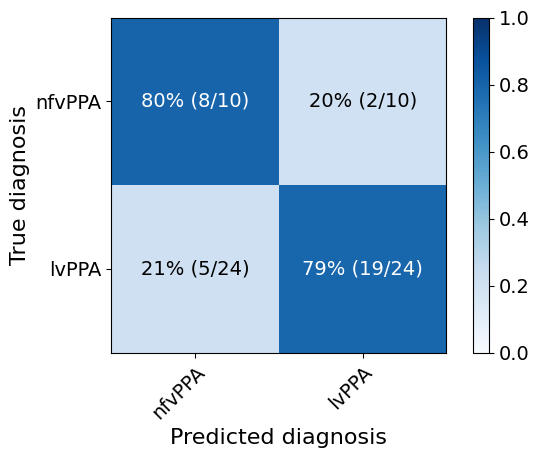

In [ ]:
looNCVWithTiming(param_grid=decision_tree_param_grid, clf=DecisionTreeClassifier(random_state=0))

#Gradient Boosting (92%)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:02<01:31,  2.78s/it]

Best params for outer fold [0]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 50}
Test idx 0: cv loop lasted 2.78 seconds


Outer folds:   6%|▌         | 2/34 [00:04<01:12,  2.26s/it]

Best params for outer fold [1]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 50}
Test idx 1: cv loop lasted 1.88 seconds


...

Best params for outer fold [31]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 50}
Test idx 31: cv loop lasted 1.50 seconds


Outer folds:  97%|█████████▋| 33/34 [01:02<00:01,  1.66s/it]

Best params for outer fold [32]: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50}
Test idx 32: cv loop lasted 1.49 seconds


Outer folds: 100%|██████████| 34/34 [01:03<00:00,  1.88s/it]

Best params for outer fold [33]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 50}
Test idx 33: cv loop lasted 1.50 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       1.00      0.80      0.89        10
       lvPPA       0.92      1.00      0.96        24

    accuracy                           0.94        34
   macro avg       0.96      0.90      0.92        34
weighted avg       0.95      0.94      0.94        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]
Evaluation true: [np.int64(1), n

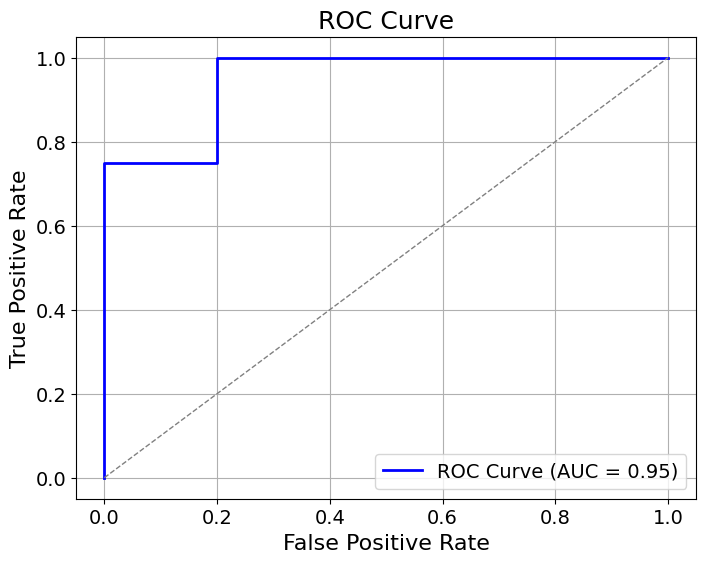

Optimal Threshold: 0.5126518622204566
Predictions using adjusted threshold: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 8  2]
 [ 0 24]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       1.00      0.80      0.89        10
       lvPPA       0.92      1.00      0.96        24

    accuracy                           0.94        34
   macro avg       0.96      0.90      0.92        34
weighted avg       0.95      0.94      0.94        34

Prettier confusion matrix for adjusted threshold:


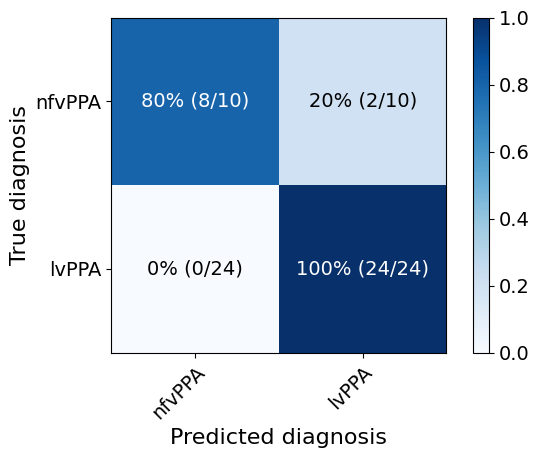

Prettier confusion matrix for default threshold:


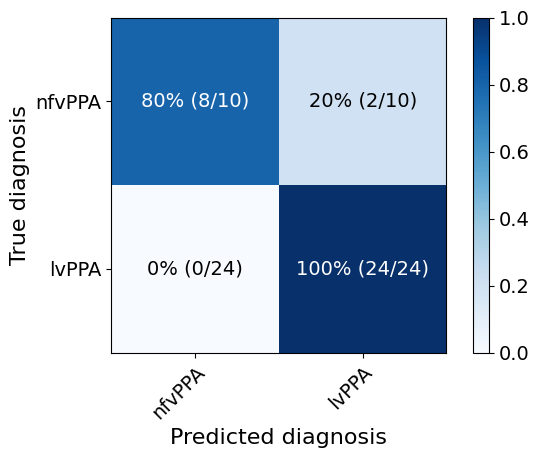

In [ ]:
gbcParamGrid = {
    "n_estimators": [12, 25, 50],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}
looNCVWithTiming(param_grid=gbcParamGrid, clf=GradientBoostingClassifier(random_state=0))

###even better confusion matrix

Ensure the x-axis labels are presented horizontally instead of diagonally

In [1]:
import numpy as np
test_true =  [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
test_true = [int(true) for true in test_true]
test_preds =  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]

In [2]:
def generateEvenBetterConfusionMatrix(test_true,test_preds):
  import matplotlib.pyplot as plt
  import numpy as np
  from sklearn.metrics import confusion_matrix
  import matplotlib.ticker as mtick

# Compute confusion matrix and normalized version
  cm = confusion_matrix(test_true, test_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  row_totals = cm.sum(axis=1)


  plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.labelsize': 16,     # x/y label size
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
  })


# Plot setup
  fig, ax = plt.subplots()
  im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)  # Use 'Blues'
  cbar = plt.colorbar(im, ax=ax)

  # Add the requested label
  cbar.set_label('Percentage of true class (%)', rotation=90, labelpad=10)
  # Change tick labels to percentages (0.2 becomes 20%, etc.)
  cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Axis setup
  class_names = ['nfvPPA', 'lvPPA']
  ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True classification',
       xlabel='Predicted classification')
#Ensure the x-axis labels are presented horizontally instead of diagonally
  plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
# Annotate each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = row_totals[i]
        percent = cm_normalized[i, j] * 100

        # Get brightness to set text color (luminance rule of thumb)
        brightness = im.cmap(cm_normalized[i, j])[:3]  # RGB
        luminance = 0.299 * brightness[0] + 0.587 * brightness[1] + 0.114 * brightness[2]
        text_color = 'black' if luminance > 0.5 else 'white'

        ax.text(j, i, f'{percent:.0f}% ({count}/{total})',
                ha='center', va='center', color=text_color, fontsize=14)

  plt.tight_layout()
  plt.show()


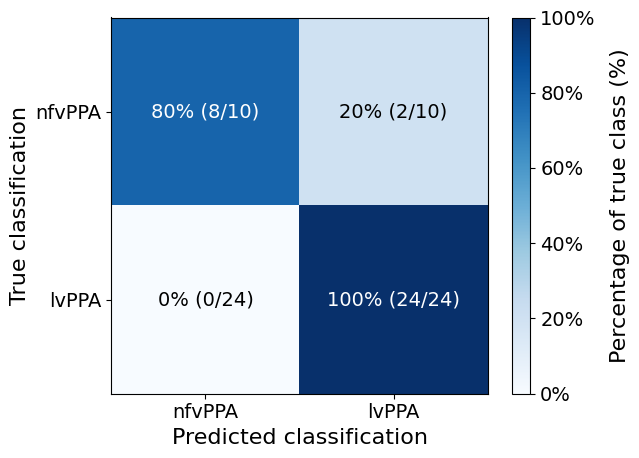

In [3]:
generateEvenBetterConfusionMatrix(test_true,test_preds)

#SVM (84%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
reducer = PCA(random_state=0)
from sklearn.svm import SVC
clf = SVC(random_state=0,class_weight='balanced',probability=True)
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('pca', reducer), ('SVM', clf)])
linear_svm_grid = {
    "SVM__kernel": ["linear"],
    "SVM__C": [0.01, 0.1, 1.0],
    "SVM__class_weight": ["balanced", None]
}
rbf_svm_grid = {
    "pca__n_components": [1,2],
    "SVM__kernel": ["rbf"],
    "SVM__C": [0.1, 1.0],
    "SVM__gamma": ["scale"],
    "SVM__class_weight": ["balanced", None]
}
svmParamGrid = [linear_svm_grid, rbf_svm_grid]

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:00<00:24,  1.37it/s]

Best params for outer fold [0]: {'SVM__C': 1.0, 'SVM__class_weight': 'balanced', 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'pca__n_components': 1}
Test idx 0: cv loop lasted 0.73 seconds


Outer folds:   6%|▌         | 2/34 [00:01<00:21,  1.50it/s]

Best params for outer fold [1]: {'SVM__C': 1.0, 'SVM__class_weight': None, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'pca__n_components': 1}
Test idx 1: cv loop lasted 0.62 seconds


...

Best params for outer fold [31]: {'SVM__C': 1.0, 'SVM__class_weight': None, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'pca__n_components': 1}
Test idx 31: cv loop lasted 0.63 seconds


Outer folds:  97%|█████████▋| 33/34 [00:24<00:00,  1.45it/s]

Best params for outer fold [32]: {'SVM__C': 0.1, 'SVM__class_weight': None, 'SVM__kernel': 'linear'}
Test idx 32: cv loop lasted 0.65 seconds


Outer folds: 100%|██████████| 34/34 [00:24<00:00,  1.36it/s]

Best params for outer fold [33]: {'SVM__C': 0.1, 'SVM__class_weight': None, 'SVM__kernel': 'linear'}
Test idx 33: cv loop lasted 0.62 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.67      0.60      0.63        10
       lvPPA       0.84      0.88      0.86        24

    accuracy                           0.79        34
   macro avg       0.75      0.74      0.74        34
weighted avg       0.79      0.79      0.79        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]
Evaluation true: [np.int

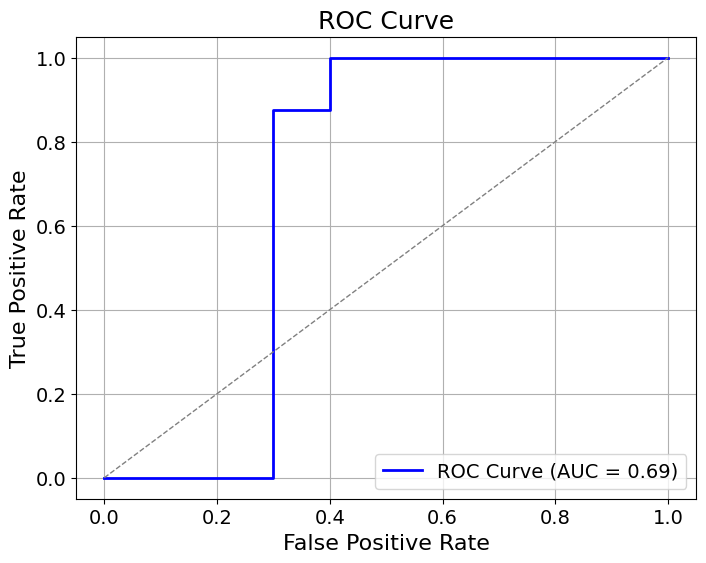

Optimal Threshold: 0.36903149595837603
Predictions using adjusted threshold: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 0 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 6  4]
 [ 0 24]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       1.00      0.60      0.75        10
       lvPPA       0.86      1.00      0.92        24

    accuracy                           0.88        34
   macro avg       0.93      0.80      0.84        34
weighted avg       0.90      0.88      0.87        34

Prettier confusion matrix for adjusted threshold:


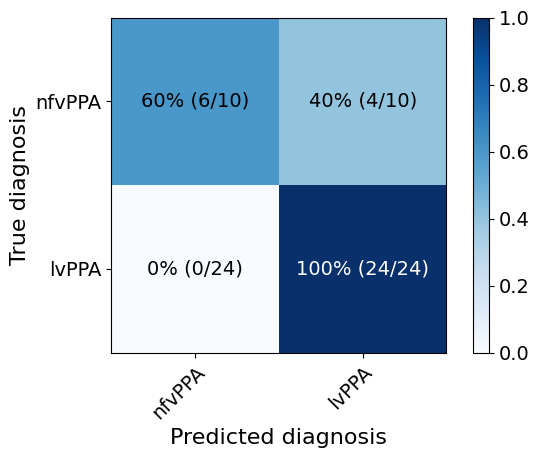

Prettier confusion matrix for default threshold:


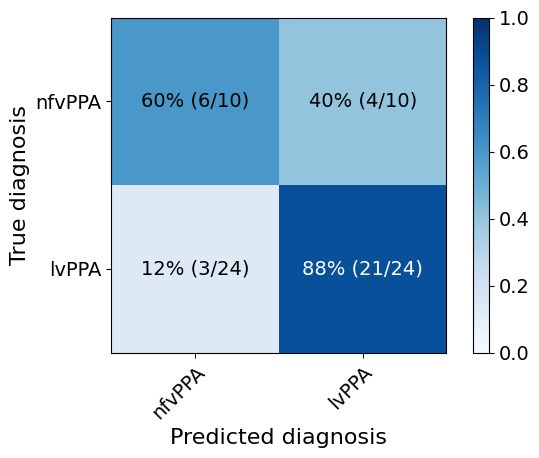

In [ ]:
looNCVWithTiming(param_grid=svmParamGrid, clf=pipe)

#Shallow Neural Net (84%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    random_state=0,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10
)

In [ ]:
snn_param_grid = {
    "MLP__hidden_layer_sizes": [
        (5,), #minimal nonlinearity
        (10,), #moderate flexibility
        (15,) #Hidden units ≲ number of features
    ],
    "MLP__activation": [
        "tanh", #Zero-centered, stable for small datasets
        "relu" #default activation function
    ],
    "MLP__alpha": [
        1e-4,
        1e-3,
        1e-2
    ],
    "MLP__solver": [
        "adam"
    ]
}


Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:01<00:53,  1.61s/it]

Best params for outer fold [0]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 0: cv loop lasted 1.61 seconds


Outer folds:   6%|▌         | 2/34 [00:03<00:50,  1.58s/it]

Best params for outer fold [1]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 1: cv loop lasted 1.56 seconds


...

Best params for outer fold [31]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 31: cv loop lasted 1.44 seconds


Outer folds:  97%|█████████▋| 33/34 [01:08<00:01,  1.60s/it]

Best params for outer fold [32]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 32: cv loop lasted 1.41 seconds


Outer folds: 100%|██████████| 34/34 [01:10<00:00,  2.07s/it]

Best params for outer fold [33]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 33: cv loop lasted 1.43 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      1.00      0.67        10
       lvPPA       1.00      0.58      0.74        24

    accuracy                           0.71        34
   macro avg       0.75      0.79      0.70        34
weighted avg       0.85      0.71      0.72        34

Evaluation preds: [np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),

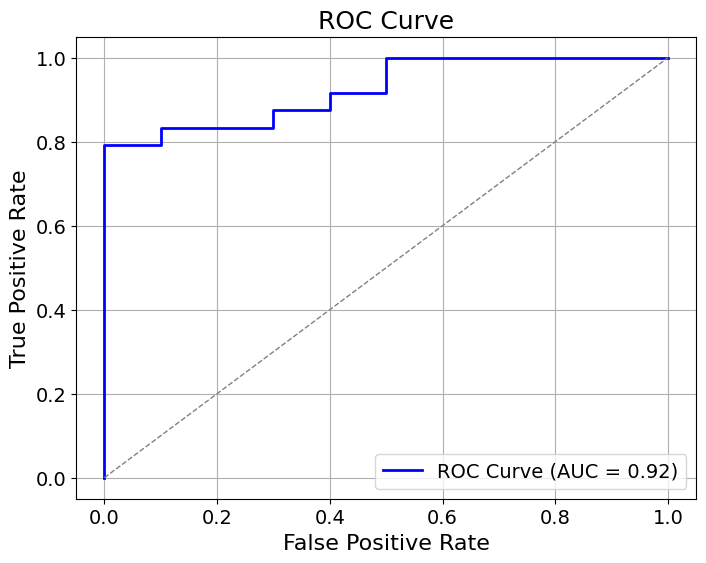

Optimal Threshold: 0.43860780169905184
Predictions using adjusted threshold: [1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0]
Confusion Matrix with Adjusted Threshold:
[[10  0]
 [ 5 19]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.67      1.00      0.80        10
       lvPPA       1.00      0.79      0.88        24

    accuracy                           0.85        34
   macro avg       0.83      0.90      0.84        34
weighted avg       0.90      0.85      0.86        34

Prettier confusion matrix for adjusted threshold:


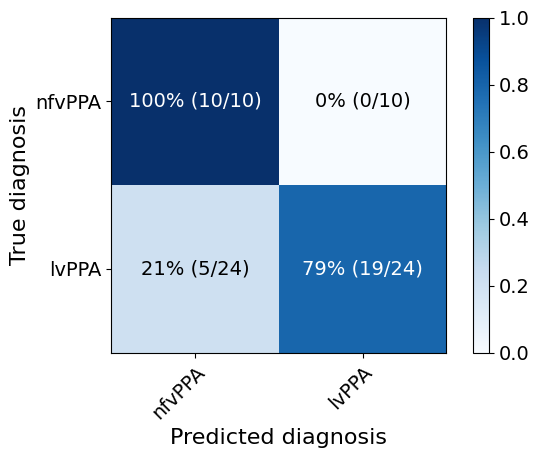

Prettier confusion matrix for default threshold:


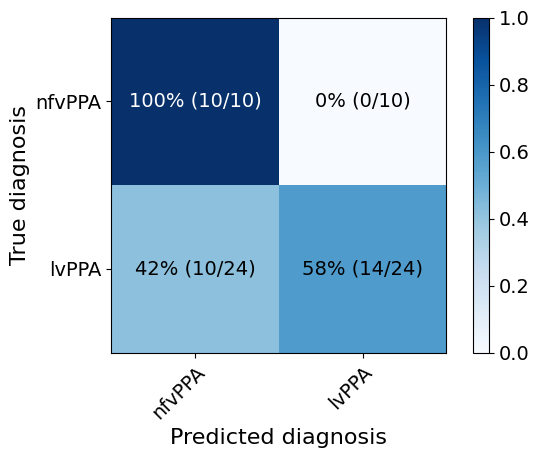

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('MLP', clf)])
looNCVWithTiming(param_grid=snn_param_grid, clf=pipe)

#Most Freq Baseline (%)



In [ ]:
#import DummyClassifier from sklearn
from sklearn.dummy import DummyClassifier
#import cross_val_predict from sklearn
from sklearn.model_selection import cross_val_predict

In [ ]:
mostfreq_baseline = DummyClassifier(strategy="most_frequent",random_state=99)
predicted = cross_val_predict(mostfreq_baseline, data_X, data_Y, cv=5)
print(predicted)
print(confusion_matrix(data_Y, predicted))
print(classification_report(data_Y, predicted,target_names=['nfvPPA','lvPPA']))
print(accuracy_score(data_Y, predicted))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 0 10]
 [ 0 24]]
              precision    recall  f1-score   support

      nfvPPA       0.00      0.00      0.00        10
       lvPPA       0.71      1.00      0.83        24

    accuracy                           0.71        34
   macro avg       0.35      0.50      0.41        34
weighted avg       0.50      0.71      0.58        34

0.7058823529411765


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Permutation analysis

##General code

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time


def looNCVPermutationImportance(clf, param_grid, threshold, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA']):
  X = data_X
  y = np.array(data_Y)
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()

  print("Running nested LOO CV with permutation importance...")

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    #print(train_idx, test_idx)
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    gridSearch = GridSearchCV(clf, param_grid, cv=5, scoring=criterion)
    gridSearch.fit(X_train, y_train)
    best_model = gridSearch.best_estimator_

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)

    # Permutation importance (with timing)
    start_time = time.time()
    result = permutation_importance(
        best_model,
        X_train,
        y_train,
        n_repeats=n_repeats,
        random_state=42,
        scoring=criterion,
        n_jobs=-1
    )
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: Permutation importance took {elapsed:.2f} seconds")

    perm_importances_per_fold.append(result.importances_mean)

# --- Aggregate permutation importances ---
  perm_importances_per_fold = np.array(perm_importances_per_fold)
  feature_names = X.columns
  mean_importances = np.mean(perm_importances_per_fold, axis=0)
  median_importances = np.median(perm_importances_per_fold, axis=0)

# --- Report ---
  importances_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importances,
    'median_importance': median_importances
  }).sort_values(by='mean_importance', ascending=False)

  print("\nPermutation Importances Across LOO CV:")
  #print(importances_df)

  # --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=class_names))

  print("Mean feature importance:", list(zip(importances_df['feature'], importances_df['mean_importance'])))
  print("Median feature importance:", list(zip(importances_df['feature'], importances_df['median_importance'])))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)
  print("Tuned threshold:", threshold)
  adjusted_test_preds = [1 if x >= threshold else 0 for x in test_preds_probs]
  print("Evaluation preds with tuned threshold:", adjusted_test_preds)
  print("Classification Report with tuned Threshold:")
  print(classification_report(test_true, adjusted_test_preds, target_names=class_names))
  #return importances_df

##run

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
gbcParamGrid = {
    "n_estimators": [12, 25, 50],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}

In [ ]:
looNCVPermutationImportance(clf=GradientBoostingClassifier(random_state=0), param_grid=gbcParamGrid, threshold=0.5126518622204566, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA'])

Running nested LOO CV with permutation importance...


Outer folds:   3%|▎         | 1/34 [02:09<1:11:29, 129.98s/it]

Test idx 0: Permutation importance took 128.19 seconds


Outer folds:   6%|▌         | 2/34 [04:13<1:07:08, 125.90s/it]

Test idx 1: Permutation importance took 120.85 seconds


...

Test idx 31: Permutation importance took 133.75 seconds


Outer folds:  97%|█████████▋| 33/34 [1:08:03<02:07, 127.51s/it]

Test idx 32: Permutation importance took 129.45 seconds


Outer folds: 100%|██████████| 34/34 [1:10:14<00:00, 123.94s/it]

Test idx 33: Permutation importance took 128.58 seconds

Permutation Importances Across LOO CV:
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       1.00      0.80      0.89        10
       lvPPA       0.92      1.00      0.96        24

    accuracy                           0.94        34
   macro avg       0.96      0.90      0.92        34
weighted avg       0.95      0.94      0.94        34

Mean feature importance: [('Word Ratings: P(lv)', 0.3425131761375831), ('Linguistic: P(lv)', 0.29149525647351676), ('Image-Text Sim: P(lv)', 0.00170021891109385), ('Speech-timing: P(lv)', 0.0)]
Median feature importance: [('Word Ratings: P(lv)', 0.34056546594620996), ('Linguistic: P(lv)', 0.2891779322163986), ('Image-Text Sim: P(lv)', 0.0), ('Speech-timing: P(lv)', 0.0)]
Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64

In [ ]:
meanFeatSetImportance = [('Word Ratings: P(lv)', 0.3425131761375831), ('Linguistic: P(lv)', 0.29149525647351676), ('Image-Text Sim: P(lv)', 0.00170021891109385), ('Speech-timing: P(lv)', 0.0)]
meanFeatSetImportance = [(featSet, importance*100) for featSet, importance in meanFeatSetImportance]
meanFeatSetImportance

[('Word Ratings: P(lv)', 34.25131761375831),
 ('Linguistic: P(lv)', 29.149525647351677),
 ('Image-Text Sim: P(lv)', 0.170021891109385),
 ('Speech-timing: P(lv)', 0.0)]